In [1]:
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

from tqdm import tqdm
from paretoset import paretoset

import model_functions as fmodel

# Matrix ISA Model Example Usage

100%|██████████| 7/7 [00:00<00:00, 983.69it/s]


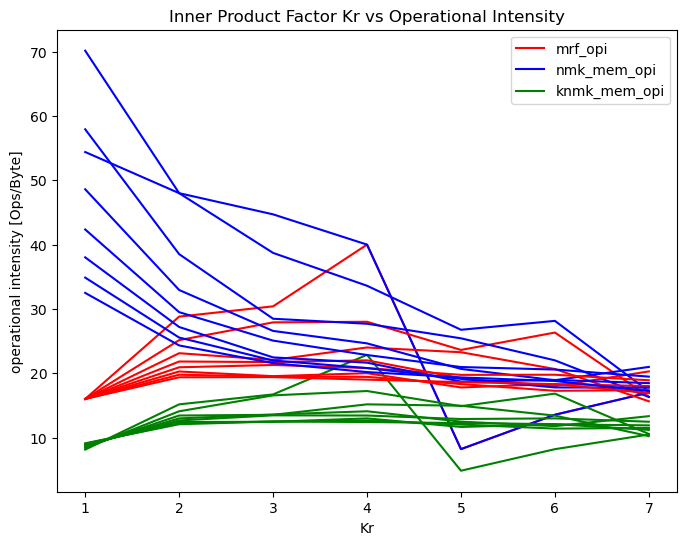

In [2]:
fig, axs = plt.subplots(figsize=(8,6))
axs.set_title('Inner Product Factor Kr vs Operational Intensity')
axs.set_xlabel('Kr')
axs.set_ylabel('operational intensity [Ops/Byte]')

kls = np.array(range(1,8))
for K in range(4,64, 8):

    perf_model = fmodel.init_pm(K=np.array([K]), kl=kls)

    # x = perf_model.index.levels[level]
    knmk_mem_bw = perf_model['knmk_mem_bw']
    nmk_mem_bw = perf_model['nmk_mem_bw']
    mem_bw = perf_model['mrf_bw']

    mrf_bw = perf_model['mrf_bw']
    opc = perf_model['ops_cycle']
    knmk_mem_opi = opc/knmk_mem_bw
    nmk_mem_opi = opc/nmk_mem_bw
    mrf_opi = opc/mrf_bw

    axs.plot(kls, mrf_opi, color='r')
    axs.plot(kls, nmk_mem_opi, color='b')
    axs.plot(kls, knmk_mem_opi, color='g')

axs.legend(['mrf_opi', 'nmk_mem_opi', 'knmk_mem_opi'])


100%|██████████| 1/1 [00:00<00:00, 754.37it/s]


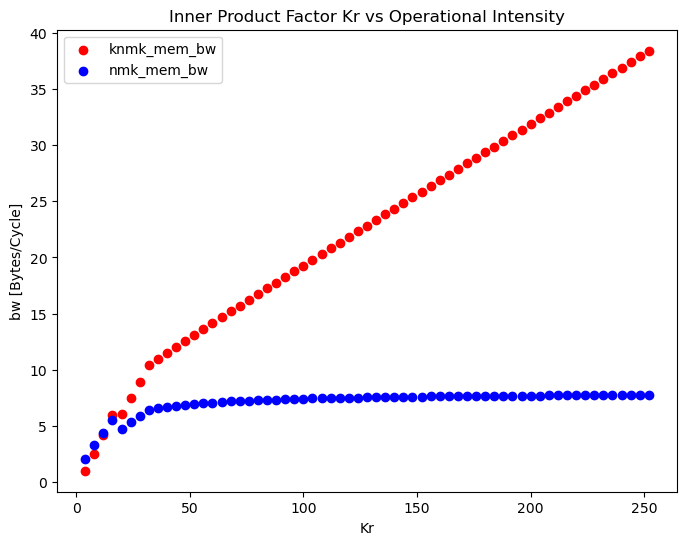

In [3]:
fig, axs = plt.subplots(figsize=(8,6))
axs.set_title('Inner Product Factor Kr vs Operational Intensity')
axs.set_xlabel('Kr')
axs.set_ylabel('bw [Bytes/Cycle]')

kls = np.array(range(1,8))
for K in range(4,256, 4):

    perf_model = fmodel.init_pm(vlB=np.array([128/8]),
                                mlB=np.array([128/8]),
                                kl=np.array([4]),
                                M=np.array([K]),
                                N=np.array([K]),
                                K=np.array([K]))

    # x = perf_model.index.levels[level]
    knmk_mem_bw = perf_model['knmk_mem_bw']
    nmk_mem_bw = perf_model['nmk_mem_bw']
    mrf_bw = perf_model['mrf_bw']

    axs.scatter(K, knmk_mem_bw, color='r')
    axs.scatter(K, nmk_mem_bw, color='b')

axs.legend(['knmk_mem_bw', 'nmk_mem_bw'])

100%|██████████| 8/8 [00:00<00:00, 1013.82it/s]


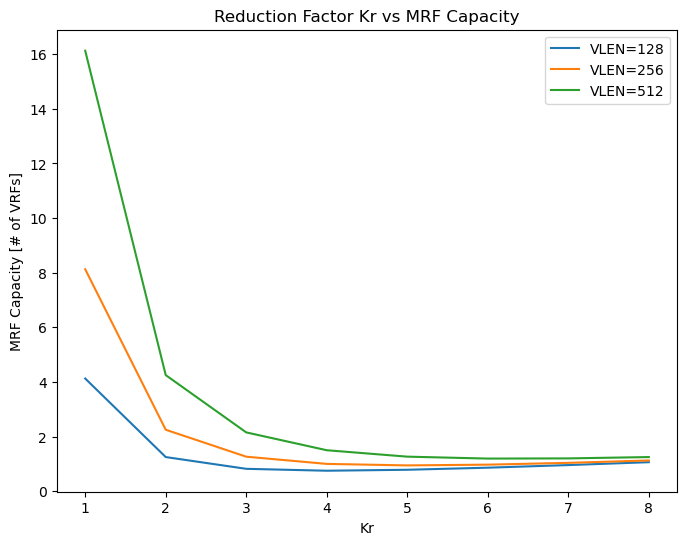

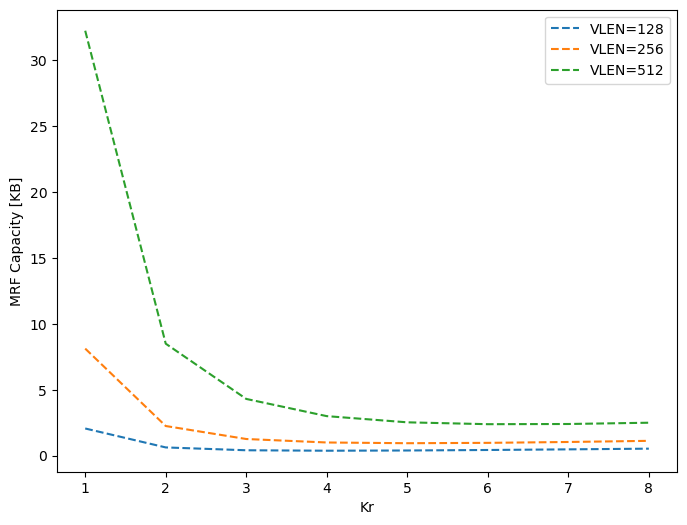

t_uk  \
databits t_mem M  N  K   l2_cache kl vlB  mlB  num_mregs t_op widen width_mmu                
8        20    64 64 800 256      1  64.0 64.0 2         0    4     1           566.222222   
                                  2  64.0 64.0 2         0    4     1          1049.777778   
                                  3  64.0 64.0 2         0    4     1          1514.370370   
                                  4  64.0 64.0 2         0    4     1          1974.222222   
                                  5  64.0 64.0 2         0    4     1          2432.177778   
                                  6  64.0 64.0 2         0    4     1          2889.185185   
                                  7  64.0 64.0 2         0    4     1          3345.650794   
                                  8  64.0 64.0 2         0    4     1          3801.777778   

                                                                                   util  \
databits t_mem M  N  K   l2_cache kl vlB  mlB  num_mregs t_op widen width_mmu             
8        20    64 64 800 256      1  64.0 64.0 2         0    4     1          1.000000   
                                  2  64.0 64.0 2         0    4     1          1.000000   
                                  3  64.0 64.0 2         0    4     1          0.997503   
                                  4  64.0 64.0 2         0    4     1          1.000000   
                                  5  64.0 64.0 2         0    4     1          1.000000   
                                  6  64.0 64.0 2         0    4     1          0.997512   
                                  7  64.0 64.0 2         0    4     1          0.997516   
                                  8  64.0 64.0 2         0    4     1          1.000000   

                                                                                 ops_cycle  \
databits t_mem M  N  K   l2_cache kl vlB  mlB  num_mregs t_op widen width_mmu                
8        20    64 64 800 256      1  64.0 64.0 2         0    4     1          4096.000000   
                                  2  64.0 64.0 2         0    4     1          2048.000000   
                                  3  64.0 64.0 2         0    4     1          1361.924261   
                                  4  64.0 64.0 2         0    4     1          1024.000000   
                                  5  64.0 64.0 2         0    4     1           819.200000   
                                  6  64.0 64.0 2         0    4     1           680.968491   
                                  7  64.0 64.0 2         0    4     1           583.689086   
                                  8  64.0 64.0 2         0    4     1           512.000000   

                                                                               max_mregs  \
databits t_mem M  N  K   l2_cache kl vlB  mlB  num_mregs t_op widen width_mmu              
8        20    64 64 800 256      1  64.0 64.0 2         0    4     1                2.0   
                                  2  64.0 64.0 2         0    4     1                2.0   
                                  3  64.0 64.0 2         0    4     1                2.0   
                                  4  64.0 64.0 2         0    4     1                2.0   
                                  5  64.0 64.0 2         0    4     1                2.0   
                                  6  64.0 64.0 2         0    4     1                2.0   
                                  7  64.0 64.0 2         0    4     1                2.0   
                                  8  64.0 64.0 2         0    4     1                2.0   

                                                                               max_mrf_capacity  \
databits t_mem M  N  K   l2_cache kl vlB  mlB  num_mregs t_op widen width_mmu                     
8        20    64 64 800 256      1  64.0 64.0 2         0    4     1                 32.250000   
                                  2  64.0 64.0 2         0    4     1      

In [4]:
fig, axs = plt.subplots(figsize=(8,6))
axs.set_title('Reduction Factor Kr vs MRF Capacity')
axs.set_xlabel('Kr')
axs.set_ylabel('MRF Capacity [# of VRFs]')

fig2, ax2 = plt.subplots(figsize=(8,6))
ax2.set_xlabel('Kr')
ax2.set_ylabel('MRF Capacity [KB]')

kls = np.array(range(1,9))
for vlB in np.array([128, 256, 512])/8:

    perf_model = fmodel.init_pm(databits=np.array([8]), 
                                vlB=np.array([vlB]), 
                                mlB=np.array([vlB]), 
                                K=np.array([100*8]), 
                                kl=kls)

    mrf_capacity = perf_model['mrf_capacity']
    max_mrf_capacity = perf_model['max_mrf_capacity']

    axs.plot(kls, mrf_capacity*2**10/(vlB*32))
    ax2.plot(kls, max_mrf_capacity, linestyle='--')

axs.legend(['VLEN=128', 'VLEN=256', 'VLEN=512'])
ax2.legend(['VLEN=128', 'VLEN=256', 'VLEN=512'])
plt.show()
perf_model

### Exploring Design Space

The model can be used to sweep ranges of the input parameters, and the output performance specs can be visualized using pareto-optimal curves.

With these plots we can visualize the tradeoffs between ngates capacity, memory bandwidth, and performance (operations per cycle).

In [ ]:
perf_model = fmodel.init_pm(
    mlB = np.array(range(128,513, 128))/8,
    vlB = np.array([128, 256, 512])/8,
    kl = np.array([1,2,4,8]),
    N = np.array(range(4,64, 8)),
    M = np.array(range(4,64, 8)),
    K = np.array(range(4,64, 8)),
    num_mregs = np.array(range(2,6,2)),
    t_op = np.array([2]),
    widen = np.array([4]),
    width_mmu = np.array([1])
)


 78%|███████▊  | 38155/49152 [00:34<00:09, 1119.12it/s]

In [ ]:
fperf_model = perf_model.copy()
fperf_model = fperf_model[fperf_model['max_mem_bw'] <= 64]
fperf_model = fperf_model[fperf_model['mrf_capacity'] <= 128]
fperf_model = fperf_model[fperf_model['ops_cycle'] >= 1/0.2e-1]

pm_pareto = fperf_model[['ops_cycle','opu_gates', 'max_mem_bw']]
mask = paretoset(pm_pareto, sense=['max', 'min', 'min'])

bw = fperf_model.loc[mask,'max_mem_bw']
ngates = fperf_model.loc[mask,'opu_gates']
opc = fperf_model.loc[mask,'ops_cycle']

fig, axs = plt.subplots(1,figsize=(6,6))
axs.set_title('Pareto Optimal Front')
axs.set_xlabel('Cycles per Operation')
axs.set_ylabel('Estimated Area [cmos gates]')

scatter = axs.scatter(1/opc, ngates, c=bw, cmap='viridis', s=100)
axs.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
fig.colorbar(scatter, ax=axs, label='Memory Bandwidth [Bytes/cycle]')
fperf_model[mask]

KeyError: 'max_mem_bw'

In [ ]:
mrf = fperf_model.loc[mask, 'mrf_capacity']
fig, axs = plt.subplots(1, figsize=(6, 6))
kls = fperf_model.loc[mask].index.get_level_values('kl')
scatter = axs.scatter(1/opc, mrf, c=kls, cmap='viridis', norm=LogNorm())
axs.set_xlabel('Cycles per Operation')
axs.set_ylabel('MRF Capacity [B/Cycle]')
axs.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
fig.colorbar(scatter, ax=axs, label='Kr (Reduction Factor)')
plt.show()

In [ ]:
fig, axs = plt.subplots(1, figsize=(6, 6))
kls = fperf_model.loc[mask].index.get_level_values('kl')
scatter = axs.scatter(1/opc, bw, c=kls, cmap='viridis', norm=LogNorm())
axs.set_xlabel('Cycles per Operation')
axs.set_ylabel('Memory Bandwidth [Bytes/Cycle]')
axs.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
fig.colorbar(scatter, ax=axs, label='Kr (Reduction Factor)')
plt.show()

In [ ]:
mrf = fperf_model.loc[mask, 'mrf_capacity']
mrf_bw = fperf_model.loc[mask, 'mrf_bw']
fig, axs = plt.subplots(1, figsize=(6, 6))
kls = fperf_model.loc[mask].index.get_level_values('kl')
scatter = axs.scatter(1/opc, mrf_bw, c=kls, cmap='viridis', norm=LogNorm())
axs.set_xlabel('Cycles per Operation')
axs.set_ylabel('MRF Bandwidth [Bytes/Cycle]')
axs.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
fig.colorbar(scatter, ax=axs, label='Kr (Reduction Factor)')
plt.show()

#### Memory Data Reuse
If the matrices are sufficiently large to reuse tiles, then bandwidth can be decreased:

In [ ]:
no_reuse_pm = perf_model.copy()
pm_pareto = no_reuse_pm[['ops_cycle','max_mem_bw']]
mask = paretoset(pm_pareto, sense=['max', 'min'])

bw = no_reuse_pm.loc[mask,'max_mem_bw']
opc = no_reuse_pm.loc[mask,'ops_cycle']

fig, axs = plt.subplots(1,figsize=(6,6))
scatter = axs.scatter(1/opc, bw, label='With No Data Reuse')

reuse_perf_model = perf_model.copy()
reuse_perf_model = reuse_perf_model[reuse_perf_model['mem_bw'] <= 64]
reuse_perf_model = reuse_perf_model[reuse_perf_model['ops_cycle'] >= 1/(4e-2)]

pm_pareto = reuse_perf_model[['ops_cycle','mem_bw']]
reuse_mask = paretoset(pm_pareto, sense=['max', 'min'])

bw = reuse_perf_model.loc[reuse_mask,'mem_bw']
opc = reuse_perf_model.loc[reuse_mask,'ops_cycle']

scatter = axs.scatter(1/opc, bw, label='With Data Reuse')
axs.set_title('Data Reuse and Optimal Memory Bandwidth')
axs.set_xlabel('Cycles per Operation')
axs.set_ylabel('Memory Bandwidth [Bytes/cycle]')
axs.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
axs.legend()


In [ ]:
tm20_perf_model = perf_model.copy()
tm200_perf_model = fmodel.init_pm(
    t_mem = np.array([200]),
    l2_cache = np.array([256]),
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    num_mregs = np.array(range(2,12,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([1])
)
tm20_perf_model = tm20_perf_model[tm20_perf_model['mem_bw'] <= 64]
tm20_perf_model = tm20_perf_model[tm20_perf_model['opu_gates'] <= 3.2e6]
tm20_perf_model = tm20_perf_model[tm20_perf_model['ops_cycle'] >= 10]

tm200_perf_model = tm200_perf_model[tm200_perf_model['mem_bw'] <= 64]
tm200_perf_model = tm200_perf_model[tm200_perf_model['opu_gates'] <= 3.2e6]
tm200_perf_model = tm200_perf_model[tm200_perf_model['ops_cycle'] >= 10]

tm20_pm_pareto = tm20_perf_model[['ops_cycle','opu_gates']]
tm20_mask = paretoset(tm20_pm_pareto, sense=['max', 'min'])

tm200_pm_pareto = tm200_perf_model[['ops_cycle','opu_gates']]
tm200_mask = paretoset(tm200_pm_pareto, sense=['max', 'min'])

fig, axs = plt.subplots(1,figsize=(6,8))
axs.set_title('Effect of Memory Latency on Resource Count')
axs.set_xlabel('cycles per operation')
axs.set_ylabel('Estimated Area [cmos gates]')

bw = tm20_perf_model.loc[tm20_mask,'mem_bw']
ngates = tm20_perf_model.loc[tm20_mask,'opu_gates']
opc = tm20_perf_model.loc[tm20_mask,'ops_cycle']
scatter = axs.scatter(1/opc, ngates, color='b', label='t$ = 20 cycles')

bw = tm200_perf_model.loc[tm200_mask,'mem_bw']
ngates = tm200_perf_model.loc[tm200_mask,'opu_gates']
opc = tm200_perf_model.loc[tm200_mask,'ops_cycle']
scatter = axs.scatter(1/opc, ngates, color='r', label='t$ = 200 cycles')

axs.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
axs.legend()
tm200_perf_model[tm200_mask]

We can compare these tradeoffs for half-width and full-width MMU datapaths:

In [ ]:
perf_model = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    N = np.array(range(4,64, 8)),
    M = np.array(range(4,64, 8)),
    K = np.array(range(4,64, 8)),
    num_mregs = np.array(range(2,6,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([0.5, 1])
)
perf_model_t1 = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    num_mregs = np.array(range(2,12,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([1])
)
perf_model_t4 = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    num_mregs = np.array(range(2,12,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([0.5])
)
perf_model_t1 = perf_model_t1[perf_model_t1['max_mem_bw'] <= 64]
bw = perf_model_t1['max_mem_bw']
ngates = perf_model_t1['opu_gates']
opc = perf_model_t1['ops_cycle']

perf_model_t4 = perf_model_t4[perf_model_t4['max_mem_bw'] <= 64]
bw_t4 = perf_model_t4['max_mem_bw']
ngates_t4 = perf_model_t4['opu_gates']
opc_t4 = perf_model_t4['ops_cycle']

fig, axs = plt.subplots(2, figsize=(6, 8))
# Plot for full width datapath
axs[0].set_title('Full Width Datapath')
axs[0].set_xlabel('Cycles per Operation')
axs[0].set_ylabel('Estimated Area [cmos gates]')
axs[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
full = axs[0].scatter(1/opc, ngates, c=bw, cmap='autumn', label='full width')
fig.colorbar(full, ax=axs[0], label='Full Width BW [Bytes/cycle]')

# Plot for half width datapath
axs[1].set_title('Half Width Datapath')
axs[1].set_xlabel('Cycles per Operation')
axs[1].set_ylabel('Estimated Area [cmos gates]')
axs[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
half = axs[1].scatter(1/opc_t4, ngates_t4, c=bw_t4, cmap='winter', label='half width')
fig.colorbar(half, ax=axs[1], label='Half Width BW [Bytes/cycle]')
plt.tight_layout()
plt.show()


In [ ]:
perf_model_t1 = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    num_mregs = np.array(range(2,12,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([1])
)
perf_model_t4 = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    num_mregs = np.array(range(2,12,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([0.5])
)
perf_model_t1 = perf_model_t1[perf_model_t1['max_mem_bw'] <= 64]
perf_model_t1 = perf_model_t1[perf_model_t1['opu_gates'] <= 2e6]
perf_model_t1 = perf_model_t1[perf_model_t1['ops_cycle'] >= 1/3.5e-2]

pm_pareto = perf_model_t1[['ops_cycle','opu_gates', 'max_mem_bw']]
mask = paretoset(pm_pareto, sense=['max', 'min', 'min'])

bw = perf_model_t1.loc[mask,'max_mem_bw']
ngates = perf_model_t1.loc[mask,'opu_gates']
opc = perf_model_t1.loc[mask,'ops_cycle']

perf_model_t4 = perf_model_t4[perf_model_t4['max_mem_bw'] <= 64]
perf_model_t4 = perf_model_t4[perf_model_t4['opu_gates'] <= 2e6]
perf_model_t4 = perf_model_t4[perf_model_t4['ops_cycle'] >= 1/3.5e-2]

pm_pareto_t4 = perf_model_t4[['ops_cycle','opu_gates', 'max_mem_bw']]
mask_t4 = paretoset(pm_pareto_t4, sense=['max', 'min', 'min'])

bw_t4 = perf_model_t4.loc[mask_t4,'max_mem_bw']
ngates_t4 = perf_model_t4.loc[mask_t4,'opu_gates']
opc_t4 = perf_model_t4.loc[mask_t4,'ops_cycle']

fig, axs = plt.subplots(1,figsize=(8,6))
axs.set_title('Full vs Half Width Datapath')
axs.set_xlabel('Cycles per Operation')
axs.set_ylabel('Estimated Area [cmos gates]')

full = axs.scatter(1/opc, ngates, c=bw, cmap='autumn', label='full width')
fig.colorbar(full, ax=axs, label = 'Full Width BW [Bytes/cycle]')

half = axs.scatter(1/opc_t4, ngates_t4, c=bw_t4, cmap='winter', label='half width')
fig.colorbar(half, ax=axs, label = 'Half Width BW [Bytes/cycle]')
axs.ticklabel_format(style='sci', axis='x', scilimits=(0,0))


In [ ]:
perf_model_t4.loc[mask_t4]

In [ ]:
perf_model_t1.loc[mask]